# Flujo completo de neutrones en la superficie de Bucaramanga

Análisis del campo de neutrones que atraviesa el plano de la superficie (ARTI/CORSIKA + transporte en el suelo, formato MEIGA).

## Entradas
- `../Grafica-flujo-Bga/all_bga_neutron_35.shw`: flujo completo en superficie, todas las energías; neutrones que bajan (pz < 0) y que suben/albedo (pz > 0). Formato `neutron px py pz x y z 0 0 0 0 0`, momento en **MeV/c**, posiciones en **mm** (plano de 400 m × 400 m).
- `../Flujo-Arti-BGA/S3_bga_003600_neutrons.shw`: salida directa de ARTI (neutrones E > 20 MeV, 3600 s, 1 m²), momento en GeV/c, con información del primario.

## Normalización
Convención de ARTI: A = 1 m² durante t = 3600 s para ambos archivos. El tiempo de `all_bga_neutron_35.shw` no está documentado; por encima de 20 MeV hay una diferencia de ~2× con S3.

## 1. Configuración

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

# El cuaderno debe estar en la carpeta Analisis-flujo-superficie-Bga
BASE = Path.cwd()
ARCHIVO_COMPLETO = BASE.parent / "Grafica-flujo-Bga" / "all_bga_neutron_35.shw"
ARCHIVO_ARTI = BASE.parent / "Flujo-Arti-BGA" / "S3_bga_003600_neutrons.shw"
SALIDA = BASE / "resultados"
SALIDA.mkdir(exist_ok=True)

M_N = 939.56542  # MeV/c^2
AREA_M2 = 1.0
TIEMPO_S = 3600.0
NORM = AREA_M2 * TIEMPO_S

# Grupos de energía [MeV]
GRUPOS = [
    ("Térmico", 1e-12, 5e-7),          # E < 0.5 eV (corte de Cd)
    ("Epitérmico", 5e-7, 0.1),         # 0.5 eV - 100 keV
    ("Evaporación", 0.1, 20.0),        # 0.1 - 20 MeV
    ("Cascada", 20.0, 1e7),            # > 20 MeV
]

C_BAJA = "#2a78d6"
C_SUBE = "#eb6834"
C_TOTAL = "#0b0b0b"
C_ARTI = "#1baf7a"
C_GRUPOS = ["#2a78d6", "#1baf7a", "#eda100", "#e87ba4"]

plt.rcParams.update({
    "font.family": "serif", "font.size": 13, "axes.labelsize": 15,
    "legend.fontsize": 11, "pdf.fonttype": 42, "axes.grid": True,
    "grid.linestyle": ":", "grid.alpha": 0.35,
})


def guardar(fig, nombre):
    fig.savefig(SALIDA / f"{nombre}.pdf", bbox_inches="tight")
    fig.savefig(SALIDA / f"{nombre}.png", dpi=300, bbox_inches="tight")
    plt.show()


def ejes_log(ax):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.xaxis.set_major_locator(ticker.LogLocator(numticks=20))

## 2. Lectura de los archivos

Energía cinética relativista $E = \sqrt{p^2 + m_n^2} - m_n$ y $\cos\theta = p_z/p$.

In [2]:
# LECTURA
c = pd.read_csv(ARCHIVO_COMPLETO, sep=r"\s+", header=None, usecols=range(7),
                names=["part", "px", "py", "pz", "x", "y", "z"])
p = np.sqrt(c.px**2 + c.py**2 + c.pz**2).to_numpy()
E = np.sqrt(p**2 + M_N**2) - M_N
cos_t = (c.pz.to_numpy() / p)               # >0 sube, <0 baja
baja = cos_t < 0
sube = ~baja
x_m, y_m = c.x.to_numpy() / 1e3, c.y.to_numpy() / 1e3

a = pd.read_csv(ARCHIVO_ARTI, sep=r"\s+", header=None,
                names=["id", "px", "py", "pz", "x", "y", "z", "shower_id",
                       "prm_id", "prm_energy", "prm_theta", "prm_phi"])
pa = np.sqrt(a.px**2 + a.py**2 + a.pz**2).to_numpy() * 1e3
Ea = np.sqrt(pa**2 + M_N**2) - M_N
cos_a = a.pz.to_numpy() * 1e3 / pa         # ARTI: pz > 0 -> baja

print(f"Flujo completo: {len(E):,} neutrones (bajan {baja.sum():,}, suben {sube.sum():,})")
print(f"ARTI S3:        {len(a):,} neutrones")
print(f"E completo [MeV]: {E.min():.3e} – {E.max():.3e}")

Flujo completo: 1,891,124 neutrones (bajan 1,111,010, suben 780,114)
ARTI S3:        317,537 neutrones
E completo [MeV]: 3.536e-11 – 4.184e+05


## 3. Espectros diferencial y letárgico

$$\left(\frac{d\Phi}{dE}\right)_i = \frac{N_i}{A\,t\,\Delta E_i}, \qquad \left(E\frac{d\Phi}{dE}\right)_i = \frac{N_i}{A\,t\,\Delta u_i},\quad \Delta u_i=\ln(E_{i+1}/E_i)$$

10 bins por década entre $10^{-11}$ y $10^{6}$ MeV.

In [3]:
# ESPECTROS
bordes = np.logspace(-11, 6, 171)           # 10 bins/década
centros = np.sqrt(bordes[:-1] * bordes[1:])
dE = np.diff(bordes)
du = np.log(bordes[1:] / bordes[:-1])


def espectro(e):
    n, _ = np.histogram(e, bins=bordes)
    return n, n / (NORM * dE), n / (NORM * du), np.sqrt(n) / (NORM * du)


n_t, dif_t, let_t, err_t = espectro(E)
n_b, dif_b, let_b, err_b = espectro(E[baja])
n_s, dif_s, let_s, err_s = espectro(E[sube])
n_a, dif_a, let_a, err_a = espectro(Ea)

pd.DataFrame({
    "E_min_MeV": bordes[:-1], "E_max_MeV": bordes[1:], "E_centro_MeV": centros,
    "N_total": n_t, "N_baja": n_b, "N_sube": n_s, "N_ARTI_S3": n_a,
    "dPhi_dE_total": dif_t, "dPhi_dE_baja": dif_b, "dPhi_dE_sube": dif_s,
    "dPhi_dE_ARTI_S3": dif_a,
    "E_dPhi_dE_total": let_t, "E_dPhi_dE_baja": let_b, "E_dPhi_dE_sube": let_s,
    "E_dPhi_dE_ARTI_S3": let_a,
}).to_csv(SALIDA / "espectro_neutrones_superficie_bga.csv", index=False,
          float_format="%.6e")

# Máximos del espectro letárgico (total)
def pico(lo, hi, let):
    s = (centros > lo) & (centros < hi)
    i = np.argmax(np.where(s, let, -1))
    return centros[i], let[i]

picos = {
    "Térmico": pico(1e-9, 5e-7, let_t),
    "Evaporación": pico(0.1, 20, let_t),
    "Cascada": pico(20, 1e5, let_t),
}

picos

{'Térmico': (4.46683592150963e-08, 26.259133298855637),
 'Evaporación': (2.2387211385683425, 55.42080138509846),
 'Cascada': (141.25375446227582, 80.58696023783119)}

## 4. Ajuste Maxwelliano de la región térmica

$E\,d\Phi/dE = C\,(E/kT)^2\,e^{-E/kT}$ (máximo en $E = 2kT$). Un kT cercano a 25 meV confirma que el momento del archivo completo está en MeV/c.

In [4]:
# AJUSTE MAXWELLIANO (región térmica)
# E dPhi/dE = C (E/kT)^2 exp(-E/kT)   (máximo en E = 2kT)
def maxwell(Ev, C, kT):
    return C * (Ev / kT)**2 * np.exp(-Ev / kT)

s_fit = (centros > 1e-9) & (centros < 2e-7) & (n_t > 0)
popt, pcov = curve_fit(maxwell, centros[s_fit], let_t[s_fit],
                       p0=[let_t[s_fit].max() * 1.8, 2.5e-8],
                       sigma=err_t[s_fit])
kT_meV = popt[1] * 1e9
kT_err = np.sqrt(pcov[1, 1]) * 1e9
T_eff = popt[1] * 1e6 / 8.617333e-5  # K

print(f"kT = {kT_meV:.2f} ± {kT_err:.2f} meV   T_ef = {T_eff:.0f} K")

kT = 25.77 ± 1.12 meV   T_ef = 299 K


## 5. Flujo integrado por grupos de energía

Corriente $J = N/(A\,t)$ a través del plano y flujo escalar $\Phi = \sum 1/\max(|\cos\theta|, 0.1) / (A\,t)$.

In [5]:
# FLUJOS INTEGRADOS POR GRUPO
filas = []
for nombre, lo, hi in GRUPOS:
    sel = (E >= lo) & (E < hi)
    nb, ns = (sel & baja).sum(), (sel & sube).sum()
    # flujo escalar (omnidireccional): suma de 1/|cos|, con |cos| >= 0.1
    w = 1.0 / np.clip(np.abs(cos_t[sel]), 0.1, None)
    filas.append({
        "Grupo": nombre,
        "Intervalo": f"{lo:.1e}-{hi:.1e} MeV",
        "N_baja": nb, "N_sube": ns, "N_total": nb + ns,
        "J_baja_m2s": nb / NORM, "J_sube_m2s": ns / NORM,
        "J_total_m2s": (nb + ns) / NORM,
        "Albedo_sube/baja": ns / nb,
        "Fraccion_total_%": 100 * (nb + ns) / len(E),
        "Phi_escalar_m2s": w.sum() / NORM,
        "cos_medio_baja": np.abs(cos_t[sel & baja]).mean(),
        "cos_medio_sube": np.abs(cos_t[sel & sube]).mean(),
    })
tabla = pd.DataFrame(filas)
tot = {"Grupo": "Total", "Intervalo": "todo",
       "N_baja": baja.sum(), "N_sube": sube.sum(), "N_total": len(E),
       "J_baja_m2s": baja.sum() / NORM, "J_sube_m2s": sube.sum() / NORM,
       "J_total_m2s": len(E) / NORM, "Albedo_sube/baja": sube.sum() / baja.sum(),
       "Fraccion_total_%": 100.0,
       "Phi_escalar_m2s": (1 / np.clip(np.abs(cos_t), 0.1, None)).sum() / NORM,
       "cos_medio_baja": np.abs(cos_t[baja]).mean(),
       "cos_medio_sube": np.abs(cos_t[sube]).mean()}
tabla = pd.concat([tabla, pd.DataFrame([tot])], ignore_index=True)
tabla.to_csv(SALIDA / "flujo_por_grupo_energia.csv", index=False,
             float_format="%.5g")

tabla

,Grupo,Intervalo,N_baja,N_sube,N_total,J_baja_m2s,J_sube_m2s,J_total_m2s,Albedo_sube/baja,Fraccion_total_%,Phi_escalar_m2s,cos_medio_baja,cos_medio_sube
0,Térmico,1.0e-12-5.0e-07 MeV,69568,166098,235666,19.324444,46.138333,65.462778,2.387563,12.461689,122.626765,0.638778,0.686169
1,Epitérmico,5.0e-07-1.0e-01 MeV,173194,257111,430305,48.109444,71.419722,119.529167,1.484526,22.753928,226.040030,0.654862,0.678509
2,Evaporación,1.0e-01-2.0e+01 MeV,220264,322227,542491,61.184444,89.507500,150.691944,1.462913,28.686168,276.412721,0.696489,0.673443
3,Cascada,2.0e+01-1.0e+07 MeV,647984,34678,682662,179.995556,9.632778,189.628333,0.053517,36.098215,224.752135,0.917481,0.601429
4,Total,todo,1111010,780114,1891124,308.613889,216.698333,525.312222,0.702166,100.000000,849.831650,0.815277,0.674621


## 6. Comparación con ARTI directo (neutrones que bajan)

In [6]:
# Comparación con ARTI (E > umbral, neutrones que bajan)
comp = []
for umbral in [20, 50, 100, 300, 1000, 10000]:
    nc = ((E > umbral) & baja).sum()
    na = (Ea > umbral).sum()
    comp.append({"E_umbral_MeV": umbral, "N_completo_baja": nc,
                 "N_ARTI_S3": na, "Cociente": nc / na,
                 "J_completo_m2s": nc / NORM, "J_ARTI_m2s": na / NORM})
comp = pd.DataFrame(comp)
comp.to_csv(SALIDA / "comparacion_completo_vs_ARTI_S3.csv", index=False,
            float_format="%.5g")

comp

,E_umbral_MeV,N_completo_baja,N_ARTI_S3,Cociente,J_completo_m2s,J_ARTI_m2s
0,20,647984,317537,2.040657,179.995556,88.204722
1,50,569038,258721,2.199427,158.066111,71.866944
2,100,418466,170654,2.452131,116.240556,47.403889
3,300,136522,48677,2.804651,37.922778,13.521389
4,1000,25545,8707,2.933846,7.095833,2.418611
5,10000,714,168,4.250000,0.198333,0.046667


## 7. Figuras

### Figura 1. Flujo letárgico con grupos de energía

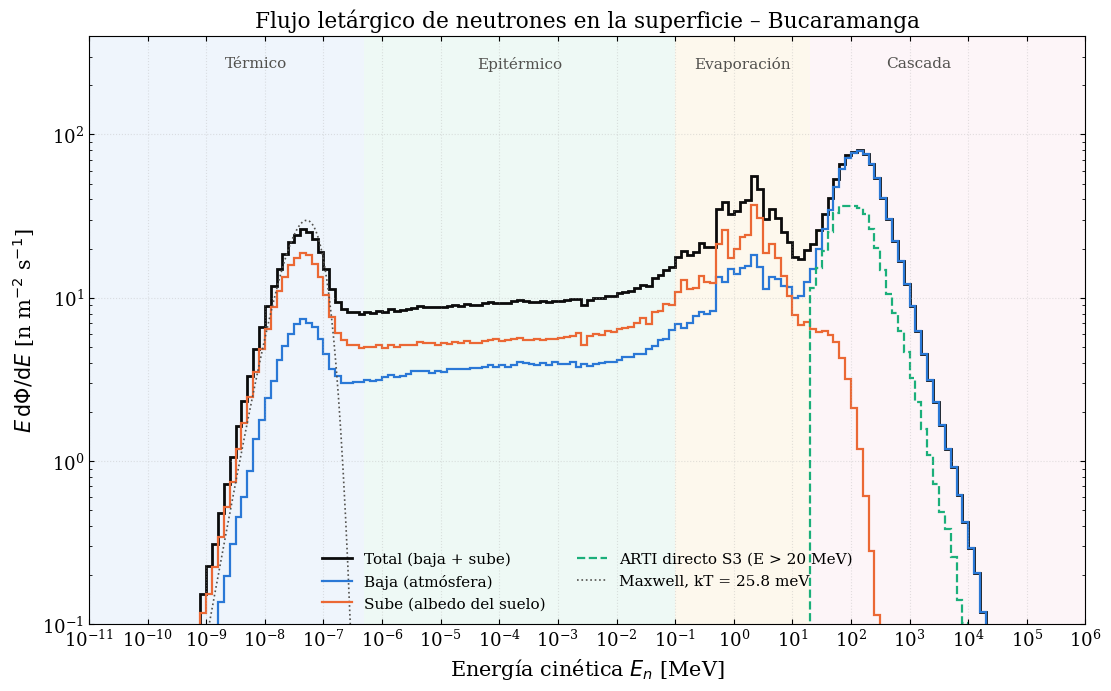

In [7]:
# FIGURA 1: espectro letárgico con grupos
fig, ax = plt.subplots(figsize=(11, 6.8), constrained_layout=True)
for (nombre, lo, hi), col in zip(GRUPOS, C_GRUPOS):
    ax.axvspan(max(lo, 1e-11), min(hi, 1e6), color=col, alpha=0.07, lw=0)
    ax.text(np.sqrt(max(lo, 1e-10) * min(hi, 1e5)), 3e2, nombre,
            ha="center", va="top", fontsize=11, color="#52514e")
ax.stairs(let_t, bordes, color=C_TOTAL, lw=2, label="Total (baja + sube)")
ax.stairs(let_b, bordes, color=C_BAJA, lw=1.6, label="Baja (atmósfera)")
ax.stairs(let_s, bordes, color=C_SUBE, lw=1.6, label="Sube (albedo del suelo)")
ax.stairs(let_a, bordes, color=C_ARTI, lw=1.6, ls="--",
          label="ARTI directo S3 (E > 20 MeV)")
Ef = np.logspace(-10, -6, 200)
ax.plot(Ef, maxwell(Ef, *popt), color="#52514e", lw=1.2, ls=":",
        label=f"Maxwell, kT = {kT_meV:.1f} meV")
ejes_log(ax)
ax.set_xlim(1e-11, 1e6)
ax.set_ylim(1e-1, 4e2)
ax.set_xlabel(r"Energía cinética $E_n$ [MeV]")
ax.set_ylabel(r"$E\,\mathrm{d}\Phi/\mathrm{d}E$ [n m$^{-2}$ s$^{-1}$]")
ax.set_title("Flujo letárgico de neutrones en la superficie – Bucaramanga")
ax.legend(loc="lower center", ncol=2, frameon=False)
guardar(fig, "fig1_flujo_letargico_superficie_bga")

### Figura 2. Flujo diferencial

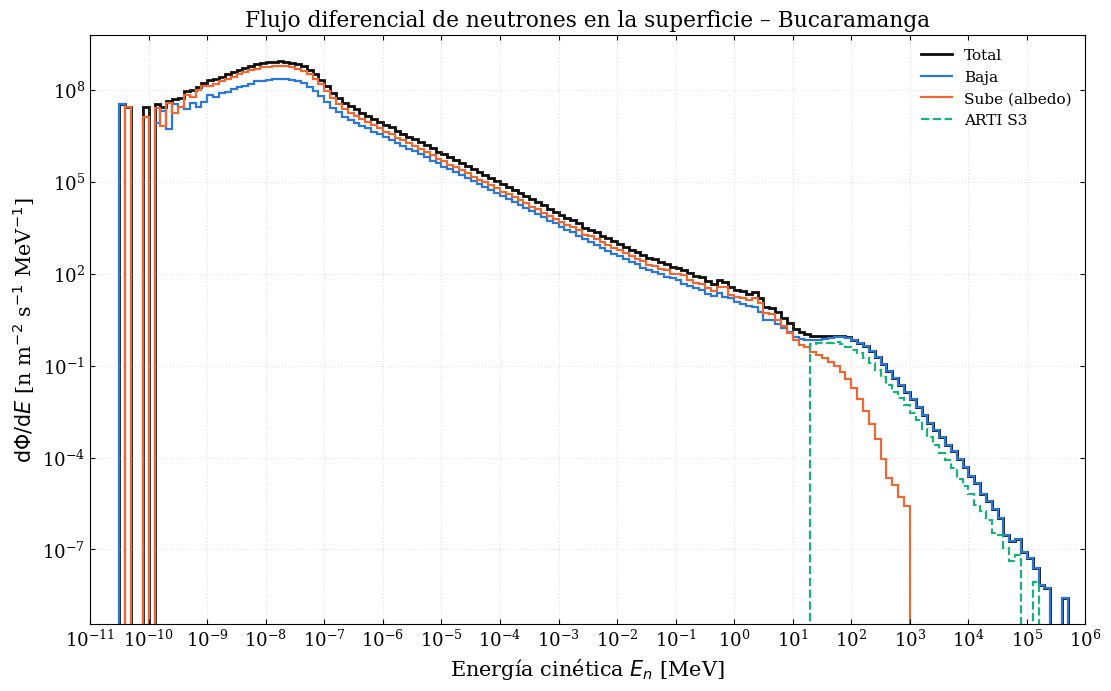

In [8]:
# FIGURA 2: diferencial
fig, ax = plt.subplots(figsize=(11, 6.8), constrained_layout=True)
ax.stairs(dif_t, bordes, color=C_TOTAL, lw=2, label="Total")
ax.stairs(dif_b, bordes, color=C_BAJA, lw=1.6, label="Baja")
ax.stairs(dif_s, bordes, color=C_SUBE, lw=1.6, label="Sube (albedo)")
ax.stairs(dif_a, bordes, color=C_ARTI, lw=1.6, ls="--", label="ARTI S3")
ejes_log(ax)
ax.set_xlim(1e-11, 1e6)
ax.set_xlabel(r"Energía cinética $E_n$ [MeV]")
ax.set_ylabel(r"$\mathrm{d}\Phi/\mathrm{d}E$ [n m$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
ax.set_title("Flujo diferencial de neutrones en la superficie – Bucaramanga")
ax.legend(frameon=False)
guardar(fig, "fig2_flujo_diferencial_superficie_bga")

### Figura 3. Distribución angular por grupo

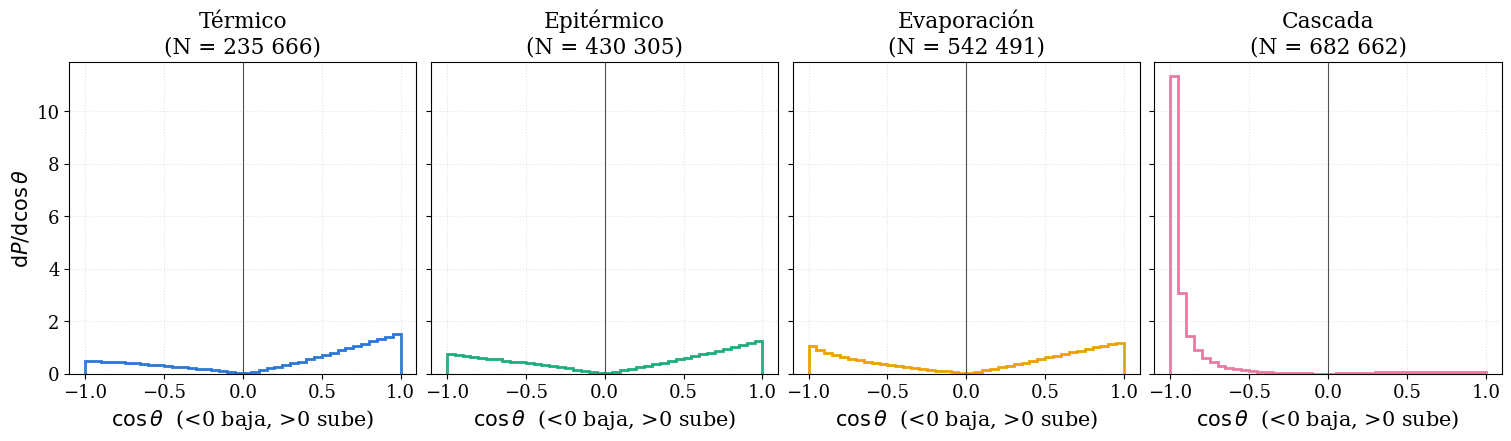

In [9]:
# FIGURA 3: distribución angular por grupo
fig, axs = plt.subplots(1, 4, figsize=(15, 4.3), sharey=True,
                        constrained_layout=True)
bc = np.linspace(-1, 1, 41)
for ax, (nombre, lo, hi), col in zip(axs, GRUPOS, C_GRUPOS):
    sel = (E >= lo) & (E < hi)
    h, _ = np.histogram(cos_t[sel], bins=bc)
    ax.stairs(h / sel.sum() / np.diff(bc), bc, color=col, lw=2, fill=False)
    ax.axvline(0, color="#52514e", lw=0.8)
    ax.set_title(f"{nombre}\n(N = {sel.sum():,})".replace(",", " "))
    ax.set_xlabel(r"$\cos\theta$  (<0 baja, >0 sube)")
axs[0].set_ylabel(r"$\mathrm{d}P/\mathrm{d}\cos\theta$")
guardar(fig, "fig3_distribucion_angular_grupos")

### Figura 4. Región térmica con el ajuste de Maxwell

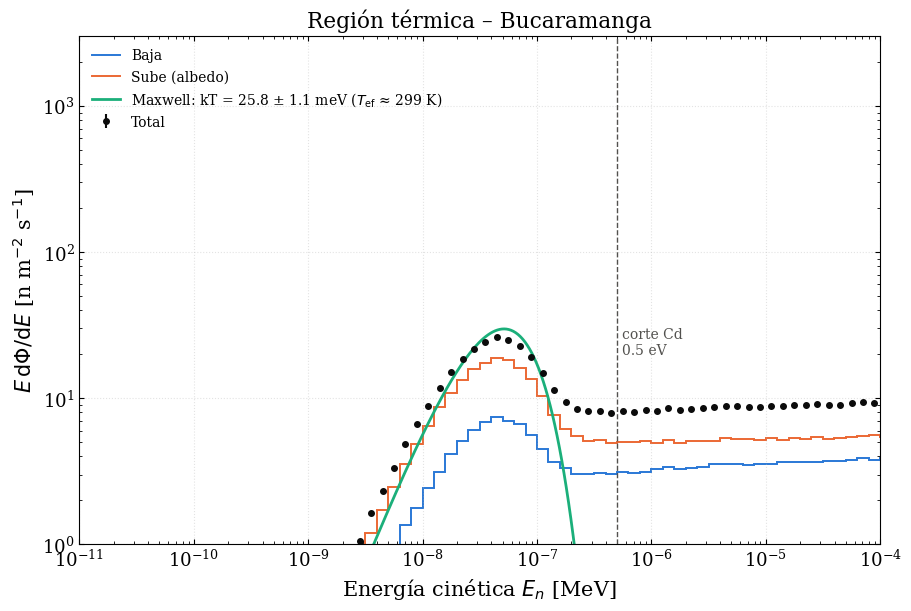

In [10]:
# FIGURA 4: región térmica con ajuste
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
ax.errorbar(centros, let_t, yerr=err_t, fmt="o", ms=4, color=C_TOTAL,
            label="Total")
ax.stairs(let_b, bordes, color=C_BAJA, lw=1.4, label="Baja")
ax.stairs(let_s, bordes, color=C_SUBE, lw=1.4, label="Sube (albedo)")
ax.plot(Ef, maxwell(Ef, *popt), color=C_ARTI, lw=2,
        label=f"Maxwell: kT = {kT_meV:.1f} ± {kT_err:.1f} meV "
              f"($T_\\mathrm{{ef}}$ ≈ {T_eff:.0f} K)")
ax.axvline(5e-7, color="#52514e", ls="--", lw=1)
ax.text(5.5e-7, 20, "corte Cd\n0.5 eV", fontsize=10, color="#52514e")
ejes_log(ax)
ax.set_xlim(1e-11, 1e-4)
ax.set_ylim(1, 3e3)
ax.set_xlabel(r"Energía cinética $E_n$ [MeV]")
ax.set_ylabel(r"$E\,\mathrm{d}\Phi/\mathrm{d}E$ [n m$^{-2}$ s$^{-1}$]")
ax.set_title("Región térmica – Bucaramanga")
ax.legend(frameon=False, fontsize=10)
guardar(fig, "fig4_region_termica_maxwell")

### Figura 5. Primarios que originan los neutrones > 20 MeV (ARTI S3)

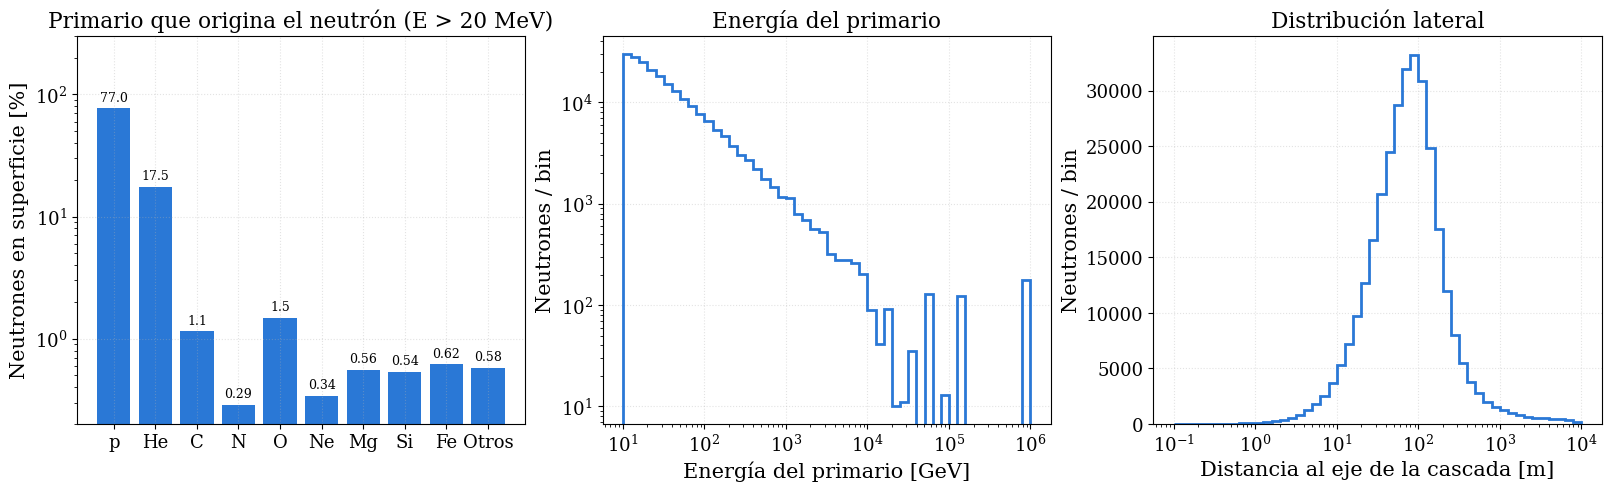

In [11]:
# FIGURA 5: primarios (ARTI S3)
nombres_prm = {14: "p", 402: "He", 703: "Li", 904: "Be", 1105: "B",
               1206: "C", 1407: "N", 1608: "O", 2010: "Ne", 2412: "Mg",
               2814: "Si", 5626: "Fe"}
cnt = a.prm_id.map(lambda k: nombres_prm.get(k, "Otros")).value_counts()
orden = ["p", "He", "C", "N", "O", "Ne", "Mg", "Si", "Fe", "Otros"]
cnt = cnt.reindex([o for o in orden if o in cnt.index]).fillna(0)
fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
axs[0].bar(cnt.index, 100 * cnt.values / cnt.sum(), color=C_BAJA)
axs[0].set_yscale("log"); axs[0].set_ylim(0.2, 300)
axs[0].set_ylabel("Neutrones en superficie [%]")
axs[0].set_title("Primario que origina el neutrón (E > 20 MeV)")
for i, v in enumerate(100 * cnt.values / cnt.sum()):
    axs[0].text(i, v * 1.15, f"{v:.1f}" if v >= 1 else f"{v:.2f}",
                ha="center", fontsize=9)
bE = np.logspace(1, 6, 51)
axs[1].hist(a.prm_energy, bins=bE, color=C_BAJA, histtype="step", lw=2)
axs[1].set_xscale("log"); axs[1].set_yscale("log")
axs[1].set_xlabel("Energía del primario [GeV]")
axs[1].set_ylabel("Neutrones / bin")
axs[1].set_title("Energía del primario")
r_m = np.hypot(a.x, a.y) / 100
axs[2].hist(r_m, bins=np.logspace(-1, 4, 51), color=C_BAJA,
            histtype="step", lw=2)
axs[2].set_xscale("log")
axs[2].set_xlabel("Distancia al eje de la cascada [m]")
axs[2].set_ylabel("Neutrones / bin")
axs[2].set_title("Distribución lateral")
guardar(fig, "fig5_primarios_ARTI_S3")

### Figura 6. Mapa en el plano de superficie

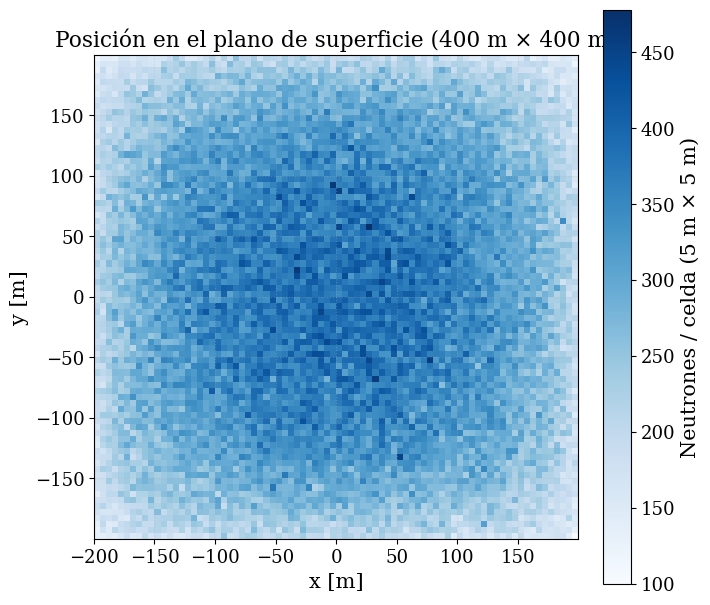

In [12]:
# FIGURA 6: mapa espacial en el plano de superficie
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
h = ax.hist2d(x_m, y_m, bins=80, cmap="Blues")
fig.colorbar(h[3], ax=ax, label="Neutrones / celda (5 m × 5 m)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_aspect("equal")
ax.set_title("Posición en el plano de superficie (400 m × 400 m)")
guardar(fig, "fig6_mapa_superficie")

## 8. Resumen y tabla LaTeX

Se escriben `resultados/resumen_flujo_superficie_bga.txt` y `resultados/tabla_flujo_grupos.tex` (usada por el informe LaTeX).

In [13]:
# RESUMEN
mult = a.groupby("shower_id").size()
frac_prm = (100 * cnt / cnt.sum()).round(2).to_dict()
with open(SALIDA / "resumen_flujo_superficie_bga.txt", "w") as f:
    f.write("FLUJO COMPLETO DE NEUTRONES EN LA SUPERFICIE – BUCARAMANGA\n")
    f.write("=" * 62 + "\n")
    f.write(f"Archivo completo: {ARCHIVO_COMPLETO.name}\n")
    f.write(f"Archivo ARTI:     {ARCHIVO_ARTI.name}\n")
    f.write(f"Normalización: A = {AREA_M2} m^2, t = {TIEMPO_S:.0f} s\n\n")
    f.write(f"Neutrones totales:  {len(E):,}\n")
    f.write(f"  bajan (pz<0):     {baja.sum():,}\n")
    f.write(f"  suben (pz>0):     {sube.sum():,}\n")
    f.write(f"E min / max [MeV]:  {E.min():.4e} / {E.max():.4e}\n")
    f.write(f"Corriente total J:  {len(E)/NORM:.2f} n m^-2 s^-1 "
            f"= {len(E)/NORM*1e-4:.4e} n cm^-2 s^-1\n")
    f.write(f"Flujo escalar Phi:  {tot['Phi_escalar_m2s']:.2f} n m^-2 s^-1 "
            "(|cos|>=0.1)\n\n")
    f.write(tabla.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
    f.write("\n\nPicos del espectro letárgico (total):\n")
    for k, (e0, v) in picos.items():
        f.write(f"  {k:12s} E = {e0:.3e} MeV   E dPhi/dE = {v:.1f}\n")
    f.write(f"\nAjuste Maxwelliano: kT = {kT_meV:.2f} ± {kT_err:.2f} meV,"
            f" T_ef = {T_eff:.0f} K\n\n")
    f.write("Comparación con ARTI directo (neutrones que bajan):\n")
    f.write(comp.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
    f.write("\n\nARTI S3 (E > 20 MeV):\n")
    f.write(f"  neutrones: {len(a):,}; cascadas: {a.shower_id.nunique():,}\n")
    f.write(f"  neutrones/cascada: media {mult.mean():.3f}, máx {mult.max()}\n")
    f.write(f"  E mediana: {np.median(Ea):.1f} MeV\n")
    f.write(f"  cos(theta) medio: {cos_a.mean():.3f}\n")
    f.write(f"  distancia al eje: mediana {np.median(r_m):.1f} m, "
            f"90% dentro de {np.percentile(r_m, 90):.0f} m\n")
    f.write(f"  primarios [%]: {frac_prm}\n")
    f.write(f"  E primario mediana: {a.prm_energy.median():.1f} GeV\n")

# Tabla LaTeX
with open(SALIDA / "tabla_flujo_grupos.tex", "w") as f:
    f.write("\\begin{tabular}{lrrrrr}\n\\hline\n")
    f.write("Grupo & $J_\\downarrow$ & $J_\\uparrow$ & $J_\\mathrm{tot}$ & "
            "$J_\\uparrow/J_\\downarrow$ & Fracción (\\%) \\\\\n")
    f.write(" & \\multicolumn{3}{c}{[n\\,m$^{-2}$\\,s$^{-1}$]} & & \\\\\n\\hline\n")
    for _, r in tabla.iterrows():
        f.write(f"{r.Grupo} & {r.J_baja_m2s:.1f} & {r.J_sube_m2s:.1f} & "
                f"{r.J_total_m2s:.1f} & {r['Albedo_sube/baja']:.2f} & "
                f"{r['Fraccion_total_%']:.1f} \\\\\n")
    f.write("\\hline\n\\end{tabular}\n")

print(open(SALIDA / "resumen_flujo_superficie_bga.txt").read())

FLUJO COMPLETO DE NEUTRONES EN LA SUPERFICIE – BUCARAMANGA
Archivo completo: all_bga_neutron_35.shw
Archivo ARTI:     S3_bga_003600_neutrons.shw
Normalización: A = 1.0 m^2, t = 3600 s

Neutrones totales:  1,891,124
  bajan (pz<0):     1,111,010
  suben (pz>0):     780,114
E min / max [MeV]:  3.5357e-11 / 4.1841e+05
Corriente total J:  525.31 n m^-2 s^-1 = 5.2531e-02 n cm^-2 s^-1
Flujo escalar Phi:  849.83 n m^-2 s^-1 (|cos|>=0.1)

      Grupo           Intervalo  N_baja  N_sube  N_total  J_baja_m2s  J_sube_m2s  J_total_m2s  Albedo_sube/baja  Fraccion_total_%  Phi_escalar_m2s  cos_medio_baja  cos_medio_sube
    Térmico 1.0e-12-5.0e-07 MeV   69568  166098   235666       19.32       46.14        65.46             2.388             12.46            122.6          0.6388          0.6862
 Epitérmico 5.0e-07-1.0e-01 MeV  173194  257111   430305       48.11       71.42        119.5             1.485             22.75              226          0.6549          0.6785
Evaporación 1.0e-01-2.0e+01 